In [97]:
import numpy as np
import matplotlib.pyplot as plt

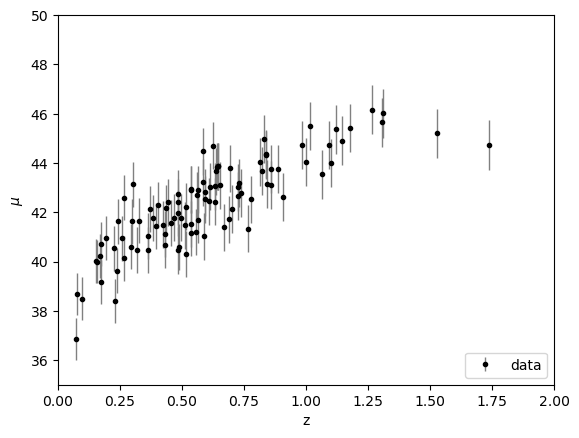

In [98]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [99]:
x_sample = np.reshape(z_sample, [100, 1])
y_sample = mu_sample
x = np.reshape(np.linspace(0, 2, 100), [100, 1])        #how many gaussians
y_err = dmu

In [100]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
        
kernel1 = 1.0 * RBF(1.0)
gp = GaussianProcessRegressor(kernel=kernel1, alpha=y_err**2)
gp.fit(x_sample, y_sample)
y_fit, y_std= gp.predict(x, return_std=True)

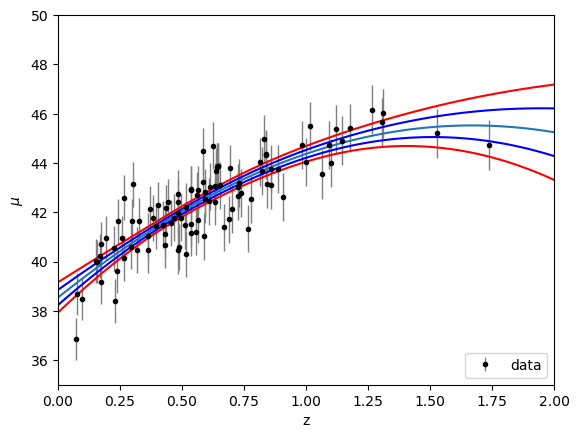

In [101]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

plt.plot(x, y_fit)
plt.plot(x, y_fit + y_std, c="blue")
plt.plot(x, y_fit - y_std, c="blue")
plt.plot(x, y_fit + 2*y_std, c="red")
plt.plot(x, y_fit - 2*y_std, c="red")

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [102]:
from sklearn.model_selection import GridSearchCV            #from W14
from sklearn.neighbors import KernelDensity

bwrange = np.linspace(0.01, 1.0, 40)
#print(bwrange)
K = 5
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K)
grid.fit(x_sample)
h_opt = grid.best_params_['bandwidth']
print(h_opt)

0.13692307692307693


Text(0.5, 1.0, 'pdf')

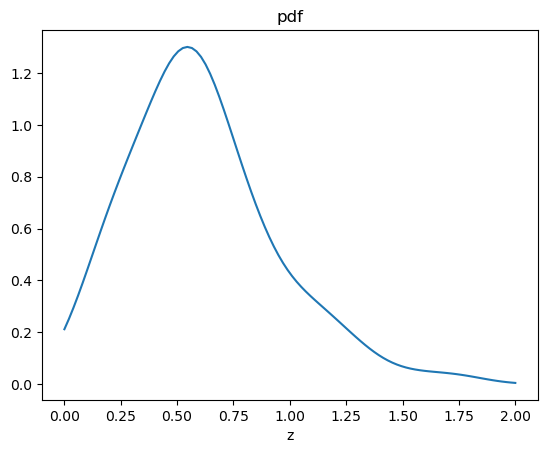

In [103]:
kde_skl = KernelDensity(bandwidth = h_opt)
kde_skl.fit(x_sample)
pdf = np.exp(kde_skl.score_samples(x))

plt.plot(x, pdf)
plt.xlabel("z")
plt.title("pdf")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


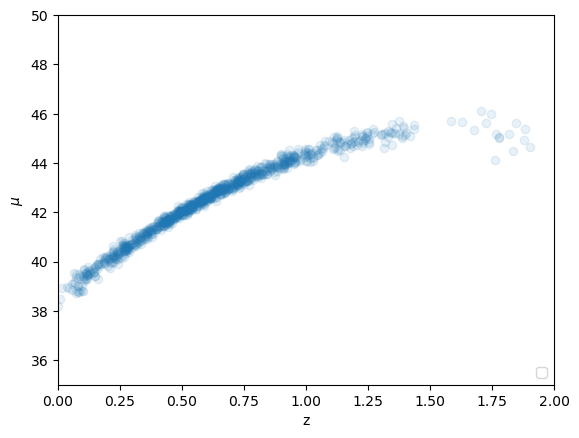

In [104]:
N = 1000
x_sample_generated = kde_skl.sample(N)        #x sample sampled from the pdf of my GPR fit

y_gpr=[]
for z in x_sample_generated.flatten():    
    y_fit, y_std = gp.predict([[z]], return_std=True)
    y_gpr.append(np.random.normal(y_fit, y_std))

plt.scatter(x_sample_generated, y_gpr, alpha=0.1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


In [105]:
from scipy.integrate import quad
import scipy.stats as scistats

def distance_modulus(params, z):
    H0, OM = params
    ODE = 1 - OM        #assume only 2 contributions
    pc = 1e-6           #in megaparsec
    c = 3e5             #km/s
  
    return np.array([5*np.log10((c/H0)/(10*pc)*(1+X)*quad(lambda x: 1/(OM*(1+x)**3 + ODE)**0.5, 0, X)[0]) for X in z])
#non è 1+z^3 ma (1+z)^3

In [106]:
#REMEMBER
#plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
#x_sample = np.reshape(z_sample, [100, 1])      is the z
#y_sample = mu_sample                           is the distance modulus
#y_err = dmu                                    is the distance modulus error                                            

#data = np.stack((z_sample, y_sample, y_err), axis=1)

#from W11
#def Likelihood(params, data, mod=distance_modulus):
#    x, y, y_std = np.transpose(data)
#    y_model = mod(params, x)
#    if params[1]<0: return 0
#    return np.prod(np.exp(-(y-y_model)**2 /2 /y_std**2))

#def Prior(params):
#    H0, OM = params
#    if 50 < H0 < 100 and 0.1 < OM < 1:
#        return 1.0/10
#    return 0


#def myPosterior(params, data, mod=distance_modulus):
#    return Likelihood(params, data, mod) * Prior(params)

# emcee wants ln of posterior pdf
#def myLogPosterior(params, data, mod=distance_modulus):
#    a = np.log(myPosterior(params, data, mod))
#    if np.isnan(a): return -np.inf
#    return a

In [107]:
#REMEMBER
#plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
#x_sample = np.reshape(z_sample, [100, 1])      is the z
#y_sample = mu_sample                           is the distance modulus
#y_err = dmu                                    is the distance modulus error                                            

#data = np.stack((z_sample, y_sample, y_err), axis=1)

#def LogLikelihood(params, data, mod=distance_modulus):
#    x, y, y_std = np.transpose(data)
#    y_model = mod(params, x)
#    if params[1]<0: return 0
#    return np.sum(-(y-y_model)**2 /2 /y_std**2)

#def LogPrior(params):
#    H0, OM = params
#    if 50 < H0 < 100 and 0.1 < OM < 1:
#        return 0
#    return -np.inf

#def LogPosterior(params, data, mod=distance_modulus):
#    return LogLikelihood(params, data, mod=distance_modulus) + LogPrior(params)

In [ ]:
#I tried my way (from W11) but tau was always NaN
def LogLikelihood(theta):
    Om,H0 = theta    
    if Om<0:
        return -np.inf
    else:
        mu_model = distance_modulus((H0, Om), z_sample)
    
    #return np.sum(scistats.norm.logpdf(mu_sample, loc=mu_model, scale=dmu))
    return np.sum(scistats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))


def Logprior(theta):
    Om,H0 = theta
    if 50 < H0 < 100 and 0.1 < Om < 1:
        return 0.0
    return -np.inf

                   
def LogPosterior(theta):
    return LogLikelihood(theta) + Logprior(theta)

In [109]:
import emcee
import corner

ndim = 2
nwalkers = 5                #12 minutes not finished with 20 walkers, I'll try 5 like the solution says (instead of 20 from W11)
                            #I also changed the model to use list comprehension instead of append
nsteps = int(1e4)

starting_guesses = np.array([0.5,80]) + 1e-1* np.random.randn(nwalkers, ndim)


In [110]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)
sampler.run_mcmc(starting_guesses, nsteps);
#10 minutes

In [111]:
samples = sampler.get_chain()
samples.shape

(10000, 5, 2)

In [112]:
tau = sampler.get_autocorr_time()
print(tau)

[54.70268797 55.09423262]


In [113]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)

(890, 2)


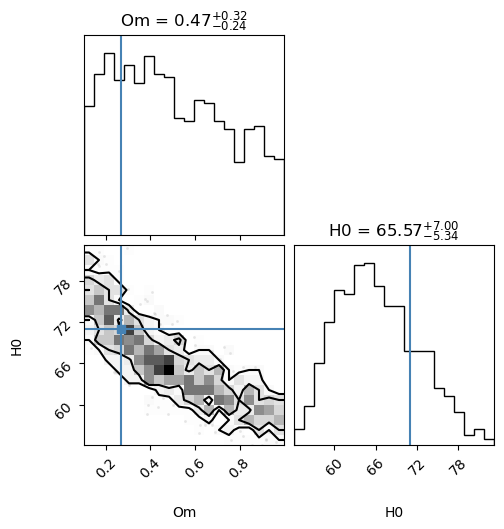

In [114]:
fig = corner.corner(
    flat_samples, labels=["Om","H0"], levels=[0.68,0.95], show_titles=True, truths=[0.27,71]
);

In [115]:
zlin = np.linspace(0,2,100)[1:]

(35.0, 50.0)

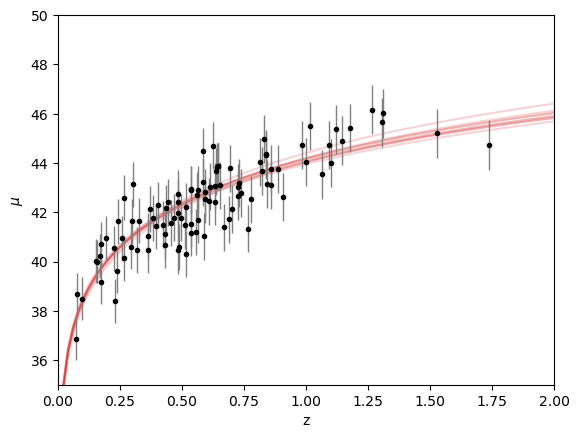

In [117]:
for Om,H0, in flat_samples[::100]:
    plt.plot(zlin, distance_modulus((H0, Om), zlin),c='C3',alpha=0.2)
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)